# Transcript Dataset: Columns and Basic Univariate EDA

This notebook performs focused EDA on `Transcripts Machine Readable Data.csv`.

Scope:
- Column inventory and schema understanding
- Basic data quality checks (missingness, duplicates, invalid markers)
- Basic univariate analysis across all metrics
- Export of summary tables for downstream use

In [8]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
print("Libraries loaded.")

Libraries loaded.


In [9]:
from pathlib import Path
import numpy as np

# Find project root
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "Transcripts Machine Readable Data.csv"
OUTPUT_DIR = ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COLS = ["Symbol", "Company Name", "Metrics"]
INVALID_TOKENS = {"#INVALID COMPANY ID": np.nan, "NA": np.nan, "": np.nan}

print("Project root:", ROOT)
print("Data path:", DATA_PATH)
print("Exists?", DATA_PATH.exists())
print("Output path:", OUTPUT_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

Project root: c:\Users\mkp22\OneDrive\Desktop\FA Project\FA-Project
Data path: c:\Users\mkp22\OneDrive\Desktop\FA Project\FA-Project\data\raw\Transcripts Machine Readable Data.csv
Exists? True
Output path: c:\Users\mkp22\OneDrive\Desktop\FA Project\FA-Project\data\processed


In [10]:
# Load and standardize raw structure
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw shape: {raw_df.shape}")

# Drop delimiter artifacts like unnamed trailing columns
unnamed_cols = [c for c in raw_df.columns if c.strip().lower().startswith("unnamed")]
if unnamed_cols:
    raw_df = raw_df.drop(columns=unnamed_cols)
    print(f"Dropped unnamed columns: {unnamed_cols}")

# Normalize header whitespace
raw_df.columns = [c.strip() for c in raw_df.columns]

# Normalize string cells and missing tokens
df = raw_df.copy()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip().replace(INVALID_TOKENS)

print(f"Cleaned shape: {df.shape}")
display(df.head(5))

Raw shape: (772, 48)
Dropped unnamed columns: ['Unnamed: 47']
Cleaned shape: (772, 47)


,Symbol,Company Name,Metrics,CQ12014,CQ22014,CQ32014,CQ42014,CQ12015,CQ22015,CQ32015,CQ42015,CQ12016,CQ22016,CQ32016,CQ42016,CQ12017,CQ22017,CQ32017,CQ42017,CQ12018,CQ22018,CQ32018,CQ42018,CQ12019,CQ22019,CQ32019,CQ42019,CQ12020,CQ22020,CQ32020,CQ42020,CQ12021,CQ22021,CQ32021,CQ42021,CQ12022,CQ22022,CQ32022,CQ42022,CQ12023,CQ22023,CQ32023,CQ42023,CQ12024,CQ22024,CQ32024,CQ42024
0,T,AT&T,Net Positivity,1.54,1.86,1.85,1.36,1.14,1.54,2.01,1.81,1.50,2.24,1.74,1.81,1.61,0.83,1.42,1.46,1.78,1.54,1.66,1.40,1.35,1.42,1.32,1.52,1.57,0.22,0.98,1.39,1.11,1.45,1.32,1.26,1.06,1.31,1.18,1.60,1.22,1.28,1.35,1.43,1.64,1.14,1.62,1.35
1,GOOGL,Alphabet Inc. (Class A),Net Positivity,1.42,1.37,1.25,1.48,0.97,1.82,1.68,1.56,1.74,2.03,1.90,1.95,1.90,2.24,1.80,1.77,1.81,2.06,1.96,1.72,1.95,1.66,1.61,1.78,1.70,0.72,1.58,1.87,1.63,1.89,1.70,1.38,1.85,1.63,1.56,1.35,2.11,2.25,2.50,2.34,2.50,2.52,2.44,2.22
2,GOOG,Alphabet Inc. (Class C),Net Positivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,META,Meta Platforms,Net Positivity,1.64,1.69,1.78,1.43,1.74,1.88,1.48,1.54,1.65,1.21,1.53,1.46,1.26,0.95,1.44,0.99,1.32,1.25,1.36,1.42,1.74,0.93,1.14,0.95,1.04,0.00,0.69,0.63,0.80,1.50,1.61,1.13,0.68,1.10,1.15,1.09,1.35,1.90,1.25,1.74,2.00,2.10,2.40,2.02
4,NFLX,Netflix,Net Positivity,0.98,1.22,1.38,0.50,0.98,0.99,1.19,1.16,1.10,1.22,0.84,1.05,1.69,1.60,2.00,1.53,1.31,1.38,1.80,1.15,1.66,1.86,1.74,1.66,1.36,1.14,2.00,0.97,1.34,1.52,1.35,1.96,1.29,1.51,1.55,1.49,1.79,1.95,1.50,1.61,1.78,1.96,2.32,2.18


In [11]:
# Column inventory and data dictionary
quarter_cols = [c for c in df.columns if c.startswith("CQ")]
non_quarter_cols = [c for c in df.columns if c not in quarter_cols]

column_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
})

column_dict["role"] = np.where(
    column_dict["column"].isin(quarter_cols),
    "quarter_value",
    np.where(column_dict["column"].isin(ID_COLS), "identifier", "other"),
)

print(f"Total columns: {len(df.columns)}")
print(f"Quarter columns: {len(quarter_cols)}")
if quarter_cols:
    print(f"Quarter range: {quarter_cols[0]} to {quarter_cols[-1]}")

display(column_dict.sort_values(["role", "column"]).reset_index(drop=True))

column_dict.to_csv(OUTPUT_DIR / "column_dictionary_and_schema.csv", index=False)

Total columns: 47
Quarter columns: 44
Quarter range: CQ12014 to CQ42024


,column,dtype,missing_count,missing_pct,n_unique,role
0,Company Name,object,0,0.00,193,identifier
1,Metrics,object,0,0.00,4,identifier
2,Symbol,object,0,0.00,193,identifier
3,CQ12014,object,8,1.04,506,quarter_value
4,CQ12015,object,8,1.04,510,quarter_value
5,CQ12016,object,8,1.04,500,quarter_value
6,CQ12017,object,8,1.04,510,quarter_value
7,CQ12018,object,8,1.04,477,quarter_value
8,CQ12019,object,8,1.04,508,quarter_value
9,CQ12020,object,8,1.04,474,quarter_value


In [12]:
# Basic quality checks
missing_summary = (
    df.isna().sum().rename("missing_count").to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)

# Duplicate check at business key
dup_key_cols = [c for c in ID_COLS if c in df.columns]
key_dup_count = int(df.duplicated(subset=dup_key_cols).sum()) if dup_key_cols else np.nan

# Rows where all quarter values are missing
all_quarter_missing_count = int(df[quarter_cols].isna().all(axis=1).sum()) if quarter_cols else np.nan

print(f"Duplicate rows by key {dup_key_cols}: {key_dup_count}")
print(f"Rows with all quarter values missing: {all_quarter_missing_count}")

display(missing_summary.head(30))

missing_summary.to_csv(OUTPUT_DIR / "missingness_summary.csv")

Duplicate rows by key ['Symbol', 'Company Name', 'Metrics']: 0
Rows with all quarter values missing: 8


,missing_count,missing_pct
CQ12019,8,1.04
CQ12022,8,1.04
CQ42019,8,1.04
CQ12020,8,1.04
CQ22020,8,1.04
CQ32020,8,1.04
CQ42020,8,1.04
CQ12021,8,1.04
CQ22021,8,1.04
CQ32021,8,1.04


In [13]:
# Reshape to long format for univariate analysis
long_df = df.melt(
    id_vars=[c for c in ID_COLS if c in df.columns],
    value_vars=quarter_cols,
    var_name="quarter",
    value_name="value",
)

# Parse quarter to date (quarter end)
quarter_pattern = long_df["quarter"].str.extract(r"^CQ([1-4])(\d{4})$")
long_df["quarter_num"] = pd.to_numeric(quarter_pattern[0], errors="coerce")
long_df["year"] = pd.to_numeric(quarter_pattern[1], errors="coerce")
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
long_df["quarter_end"] = pd.to_datetime(
    dict(year=long_df["year"], month=long_df["quarter_num"].map(month_map), day=1),
    errors="coerce",
) + pd.offsets.MonthEnd(0)

long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

dup_long = int(long_df.duplicated(subset=["Symbol", "Metrics", "quarter"]).sum())
print(f"Long shape: {long_df.shape}")
print(f"Duplicate (Symbol, Metrics, quarter) in long data: {dup_long}")
display(long_df.head())

long_df.to_csv(OUTPUT_DIR / "transcripts_long_panel.csv", index=False)

Long shape: (33968, 8)
Duplicate (Symbol, Metrics, quarter) in long data: 0


,Symbol,Company Name,Metrics,quarter,value,quarter_num,year,quarter_end
0,T,AT&T,Net Positivity,CQ12014,1.54,1,2014,2014-03-31
1,GOOGL,Alphabet Inc. (Class A),Net Positivity,CQ12014,1.42,1,2014,2014-03-31
2,GOOG,Alphabet Inc. (Class C),Net Positivity,CQ12014,NaN,1,2014,2014-03-31
3,META,Meta Platforms,Net Positivity,CQ12014,1.64,1,2014,2014-03-31
4,NFLX,Netflix,Net Positivity,CQ12014,0.98,1,2014,2014-03-31


In [14]:
# Basic univariate summary by metric
metric_summary = (
    long_df.groupby("Metrics")["value"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)

metric_missing = (
    long_df.groupby("Metrics", as_index=False)
    .agg(total_obs=("value", "size"), non_missing_obs=("value", "count"))
)
metric_missing["missing_obs"] = metric_missing["total_obs"] - metric_missing["non_missing_obs"]
metric_missing["missing_pct"] = (metric_missing["missing_obs"] / metric_missing["total_obs"] * 100).round(2)

display(metric_summary)
display(metric_missing.sort_values("missing_pct", ascending=False))

metric_summary.to_csv(OUTPUT_DIR / "metric_univariate_summary.csv", index=False)
metric_missing.to_csv(OUTPUT_DIR / "metric_missingness_summary.csv", index=False)

,Metrics,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,Analyst Selectivity Ratio,8120.0,41.818329,16.358235,0.00,4.55,17.50,30.00,40.00,52.94,69.23,81.7117,100.00
1,Language Complexity,8117.0,12.422687,1.136442,9.05,10.10,10.68,11.62,12.37,13.14,14.42,15.3200,17.74
2,Net Positivity,8117.0,1.105240,0.594777,-1.43,-0.37,0.14,0.73,1.11,1.49,2.06,2.5500,3.32
3,Numeric Transeprency,8117.0,2.328527,0.762707,0.29,0.90,1.25,1.79,2.25,2.78,3.66,4.5100,7.46


,Metrics,total_obs,non_missing_obs,missing_obs,missing_pct
1,Language Complexity,8492,8117,375,4.42
2,Net Positivity,8492,8117,375,4.42
3,Numeric Transeprency,8492,8117,375,4.42
0,Analyst Selectivity Ratio,8492,8120,372,4.38


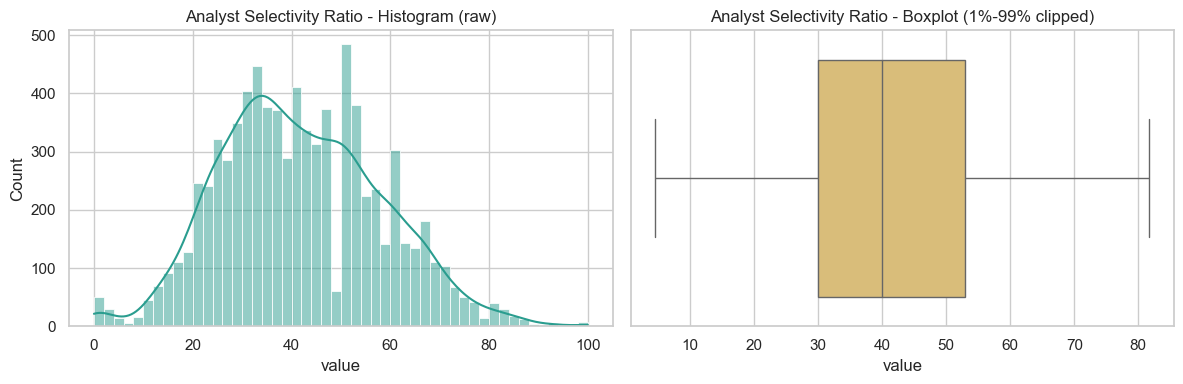

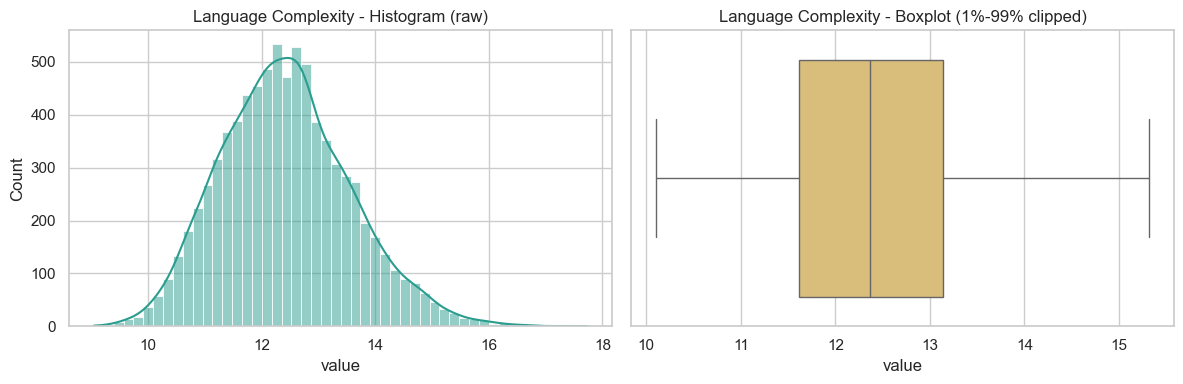

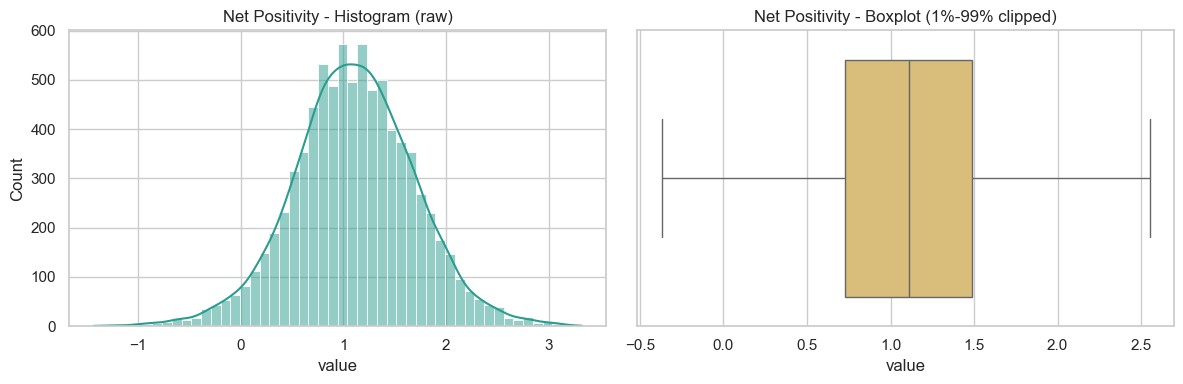

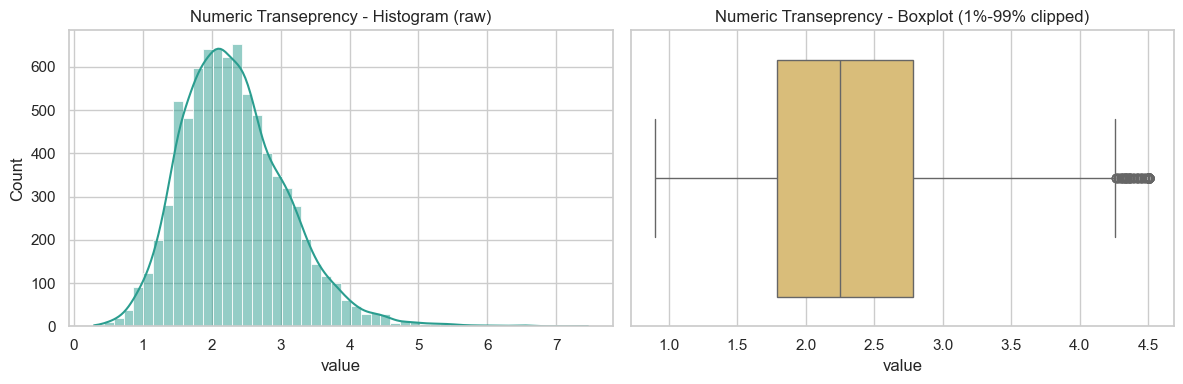

In [15]:
# Basic plots: distribution by metric (clipped for readability)
metrics = sorted(long_df["Metrics"].dropna().unique())

for metric in metrics:
    s = long_df.loc[long_df["Metrics"] == metric, "value"].dropna()
    if s.empty:
        continue

    p1, p99 = s.quantile([0.01, 0.99])
    clipped = s.clip(lower=p1, upper=p99)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(s, bins=50, kde=True, ax=axes[0], color="#2A9D8F")
    axes[0].set_title(f"{metric} - Histogram (raw)")

    sns.boxplot(x=clipped, ax=axes[1], color="#E9C46A")
    axes[1].set_title(f"{metric} - Boxplot (1%-99% clipped)")

    plt.tight_layout()
    plt.show()

,quarter,non_missing_obs
0,CQ12014,744
1,CQ12015,744
2,CQ12016,732
3,CQ12017,740
4,CQ12018,736
5,CQ12019,740
6,CQ12020,731
7,CQ12021,744
8,CQ12022,736
9,CQ12023,744


,quarter,Metrics,median_value
0,CQ12014,Analyst Selectivity Ratio,41.280
1,CQ12014,Language Complexity,12.305
2,CQ12014,Net Positivity,0.970
3,CQ12014,Numeric Transeprency,2.720
4,CQ12015,Analyst Selectivity Ratio,42.210
5,CQ12015,Language Complexity,12.350
6,CQ12015,Net Positivity,1.015
7,CQ12015,Numeric Transeprency,2.845
8,CQ12016,Analyst Selectivity Ratio,41.670
9,CQ12016,Language Complexity,12.450


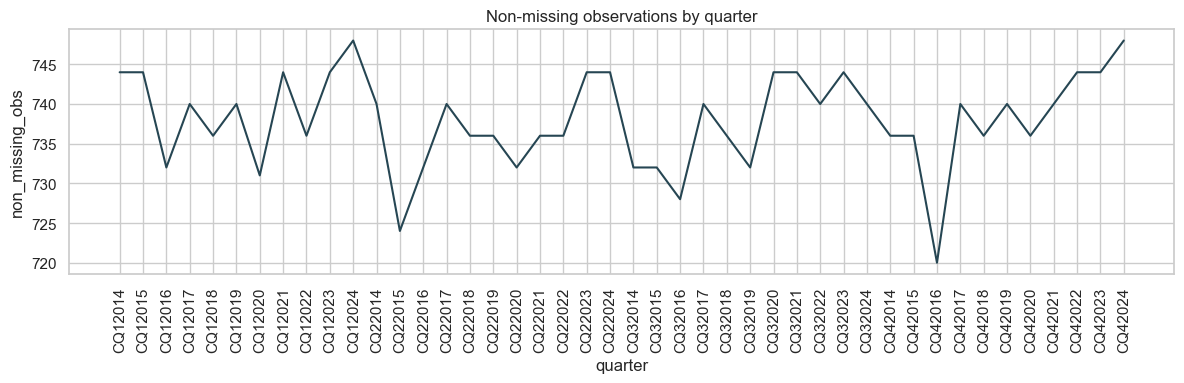

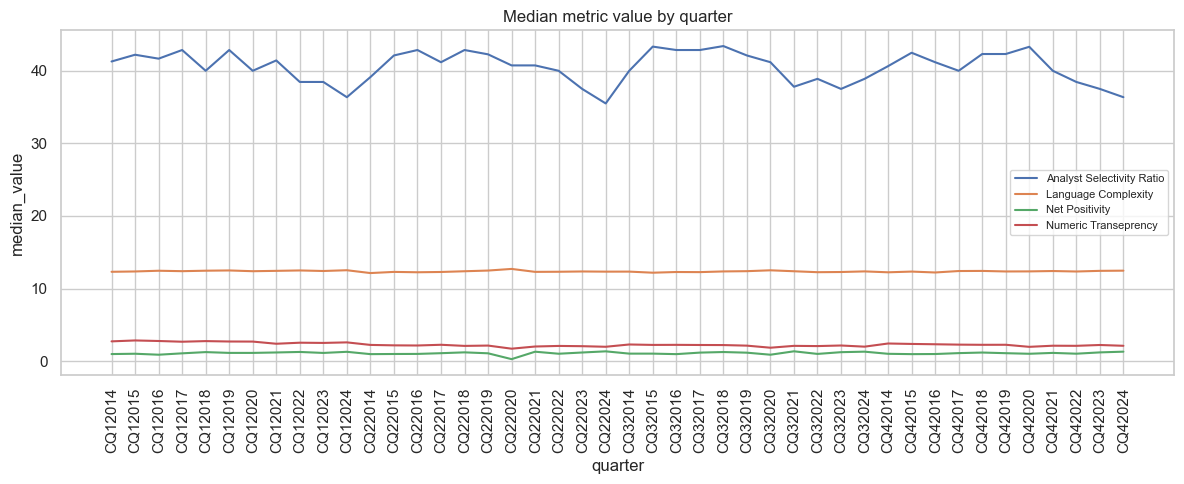

Saved outputs:
- column_dictionary_and_schema.csv
- metric_missingness_summary.csv
- metric_univariate_summary.csv
- missingness_summary.csv
- quarter_metric_medians.csv
- quarter_non_missing_counts.csv
- transcripts_long_panel.csv


In [16]:
# Basic time univariate views
quarter_counts = (
    long_df.groupby("quarter", as_index=False)
    .agg(non_missing_obs=("value", "count"))
    .sort_values("quarter")
)

quarter_median_by_metric = (
    long_df.groupby(["quarter", "Metrics"], as_index=False)["value"]
    .median()
    .rename(columns={"value": "median_value"})
)

display(quarter_counts.head(12))
display(quarter_median_by_metric.head(20))

plt.figure(figsize=(12, 4))
sns.lineplot(data=quarter_counts, x="quarter", y="non_missing_obs", color="#264653")
plt.title("Non-missing observations by quarter")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=quarter_median_by_metric, x="quarter", y="median_value", hue="Metrics")
plt.title("Median metric value by quarter")
plt.xticks(rotation=90)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

quarter_counts.to_csv(OUTPUT_DIR / "quarter_non_missing_counts.csv", index=False)
quarter_median_by_metric.to_csv(OUTPUT_DIR / "quarter_metric_medians.csv", index=False)

print("Saved outputs:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)

Final Cleaned Transcript Panel

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path("../data/raw/Transcripts Machine Readable Data.csv")
OUTPUT_DIR = Path("../data/processed")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df = df.rename(columns={
    "Symbol":"ticker",
    "Company Name":"company_name",
    "Metrics":"metric"
})

quarter_cols = [c for c in df.columns if c.startswith("CQ")]

long_df = df.melt(
    id_vars=["ticker","company_name","metric"],
    value_vars=quarter_cols,
    var_name="quarter",
    value_name="value"
)

long_df["ticker"] = long_df["ticker"].str.upper().str.strip()

long_df["value"] = long_df["value"].replace("#INVALID COMPANY ID",np.nan)

long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

metric_map = {
    "Net Positivity":"net_positivity",
    "Numeric Transeprency":"numeric_transparency",
    "Language Complexity":"language_complexity",
    "Analyst Selectivity Ratio":"analyst_selectivity_ratio"
}

long_df["metric"] = long_df["metric"].replace(metric_map)

panel = long_df.pivot_table(
    index=["ticker","quarter"],
    columns="metric",
    values="value"
).reset_index()

def quarter_to_date(q):
    q = q.replace("CQ","")
    quarter = int(q[0])
    year = int(q[1:])

    month_map = {
        1:"03-31",
        2:"06-30",
        3:"09-30",
        4:"12-31"
    }

    return pd.to_datetime(f"{year}-{month_map[quarter]}")

panel["quarter_end"] = panel["quarter"].apply(quarter_to_date)

panel = panel.sort_values(["ticker","quarter_end"])

panel.to_parquet(OUTPUT_DIR / "transcript_quarter_panel.parquet", index=False)

print("Saved transcript panel")
panel.head()

Saved transcript panel


metric,ticker,quarter,Numeric Transeprency,analyst_selectivity_ratio,language_complexity,net_positivity,quarter_end
0,A,CQ12014,2.67,64.71,11.32,0.25,2014-03-31
11,A,CQ22014,1.90,50.00,11.64,0.70,2014-06-30
22,A,CQ32014,2.19,78.57,11.91,0.97,2014-09-30
33,A,CQ42014,3.05,64.29,12.15,0.75,2014-12-31
1,A,CQ12015,1.96,75.00,12.42,0.93,2015-03-31


## Interpretation Notes (Fill After Run)

Use this section to summarize:
- Which columns are identifiers vs quarter values
- Where missingness is concentrated
- Which metrics are most/least volatile from univariate summaries
- Any obvious outliers or unusual ranges
- Whether the dataset is clean enough for downstream feature work